# Data preparation

In [1]:
!wget http://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data -O wine.data

--2018-05-01 22:29:01--  http://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.249
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.249|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10782 (11K) [text/plain]
Saving to: ‘wine.data’

wine.data           100%[===================>]  10.53K  --.-KB/s    in 0s      

2018-05-01 22:29:01 (176 MB/s) - ‘wine.data’ saved [10782/10782]



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('wine.data')

# Column names from:
# http://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.names
columns = ['vinyard','alcohol','malic acid','ash','ash alcalinity','magnesium',
           'Total phenols','Flavanoids','Nonflavanoid phenols','Proanthocyanins',
           'Color intensity','Hue','dilute OD280/OD315', 'Proline']

data.columns = columns

vinyard = data['vinyard']
data = data.drop(['vinyard'],axis=1)
colors = np.array(['red','green','blue'])[vinyard-1]

data.head()

,alcohol,malic acid,ash,ash alcalinity,magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,dilute OD280/OD315,Proline
0,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
2,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
3,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
4,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450


# Dimensionality reduction using PCA

In [0]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

def plot_3d_pca(data, colors):
  pca = PCA(n_components=3)
  pca.fit(data)
  pca_results = pca.transform(data)
    
  x, y, z = pca_results.T
  fig = plt.figure(figsize=(16, 5.5/8*16))  
  ax = fig.add_subplot(111, projection='3d')
  ax.scatter(x, y, z, color=colors);

# PCA Results

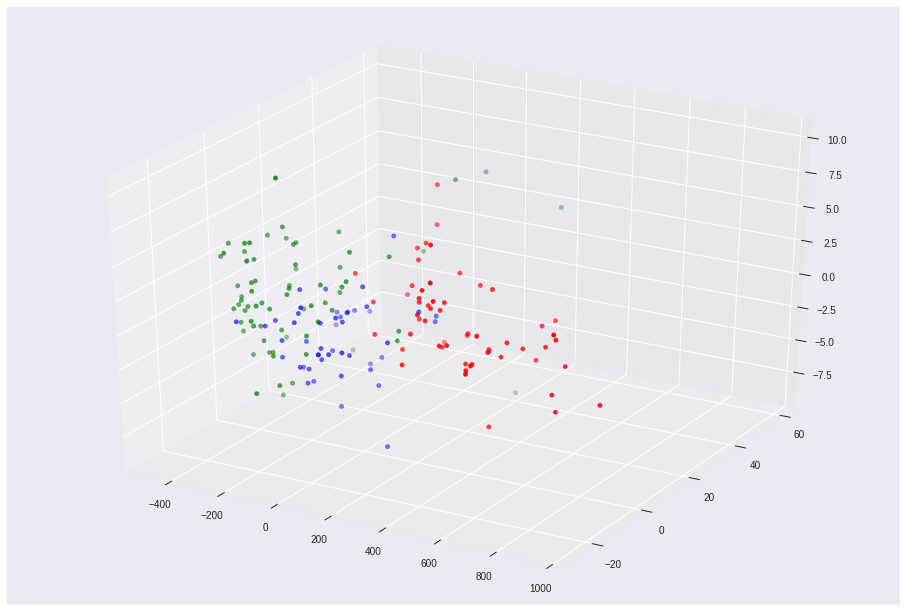

In [7]:
plot_3d_pca(data, colors)

# Normalization

### `Normalizer`

In [11]:
import sklearn.preprocessing as preprocessing
data_post_normalizer = pd.DataFrame(preprocessing.Normalizer().fit_transform(data))
data_post_normalizer.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.012513,0.001687,0.002029,0.010617,0.094794,0.002512,0.002616,0.000246,0.001213,0.004152,0.000995,0.003223,0.995336
1,0.011063,0.001984,0.002245,0.015636,0.084906,0.002354,0.002724,0.000252,0.002362,0.004775,0.000866,0.002665,0.996176
2,0.009680,0.001314,0.001684,0.011317,0.076119,0.002593,0.002351,0.000162,0.001468,0.005254,0.000579,0.002324,0.996961
3,0.017775,0.003477,0.003853,0.028193,0.158418,0.003759,0.003611,0.000524,0.002443,0.005800,0.001396,0.003934,0.986753
4,0.009763,0.001210,0.001684,0.010450,0.077002,0.002248,0.002331,0.000234,0.001354,0.004641,0.000722,0.001959,0.996907


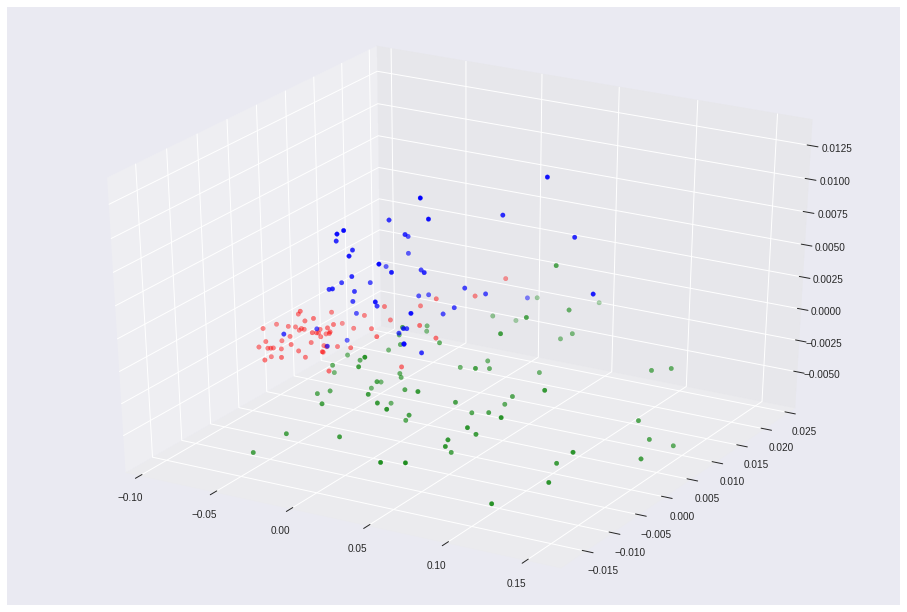

In [9]:
plot_3d_pca(data_post_normalizer, colors)

### `StandardScaler`

In [12]:
data_post_standardscaler = pd.DataFrame(preprocessing.StandardScaler().fit_transform(data))
data_post_standardscaler.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.255824,-0.501624,-0.824485,-2.500110,0.029180,0.572666,0.739636,-0.823139,-0.538575,-0.291130,0.407100,1.131698,0.971052
1,0.206229,0.018020,1.107690,-0.275639,0.099932,0.812784,1.221645,-0.501337,2.145975,0.269729,0.319567,0.804579,1.400998
2,1.706501,-0.349315,0.487935,-0.816726,0.948953,2.493609,1.472691,-0.984039,1.040572,1.184362,-0.424458,1.202811,2.340509
3,0.305420,0.224086,1.836812,0.445811,1.302712,0.812784,0.669343,0.222716,0.408913,-0.317016,0.363334,0.463238,-0.032154
4,1.495719,-0.519543,0.305655,-1.297693,0.878201,1.565153,1.372273,-0.179536,0.672104,0.731360,0.407100,0.349457,2.244965


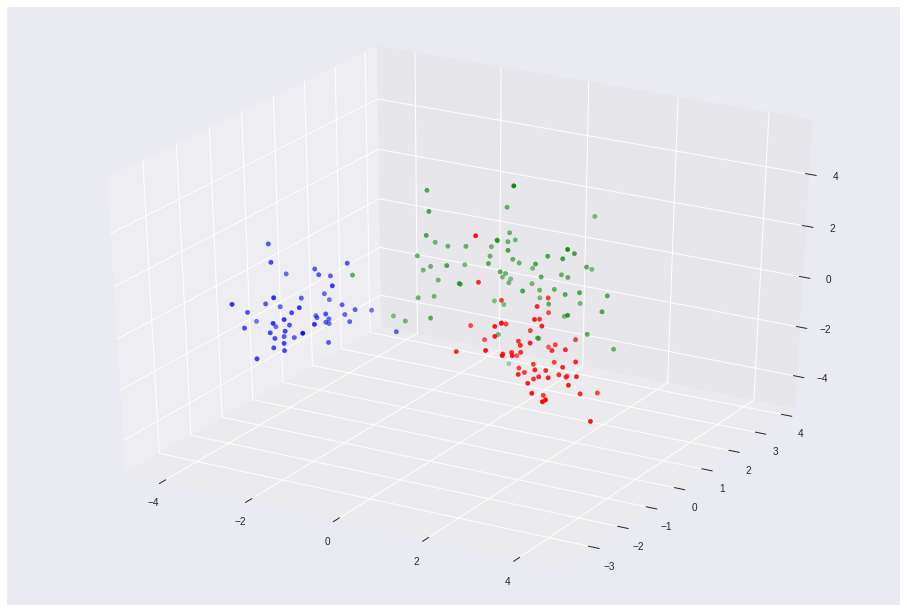

In [13]:
plot_3d_pca(data_post_standardscaler, colors)

### `MinMaxScaler`

In [14]:
data_post_minmaxscaler = pd.DataFrame(preprocessing.MinMaxScaler((0, 1)).fit_transform(data))
data_post_minmaxscaler.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.571053,0.205534,0.417112,0.030928,0.326087,0.575862,0.510549,0.245283,0.274448,0.264505,0.463415,0.780220,0.550642
1,0.560526,0.320158,0.700535,0.412371,0.336957,0.627586,0.611814,0.320755,0.757098,0.375427,0.447154,0.695971,0.646933
2,0.878947,0.239130,0.609626,0.319588,0.467391,0.989655,0.664557,0.207547,0.558360,0.556314,0.308943,0.798535,0.857347
3,0.581579,0.365613,0.807487,0.536082,0.521739,0.627586,0.495781,0.490566,0.444795,0.259386,0.455285,0.608059,0.325963
4,0.834211,0.201581,0.582888,0.237113,0.456522,0.789655,0.643460,0.396226,0.492114,0.466724,0.463415,0.578755,0.835949


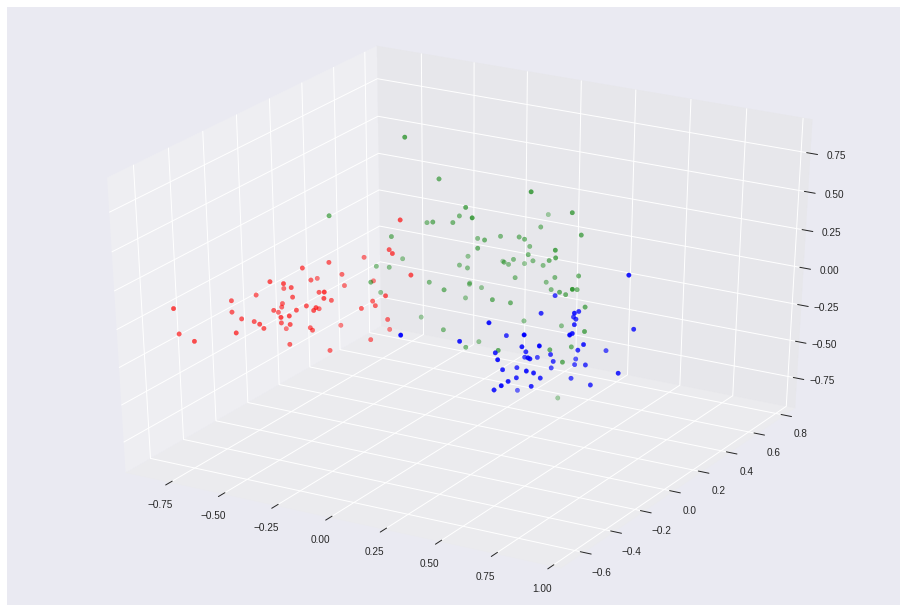

In [15]:
plot_3d_pca(data_post_minmaxscaler, colors)

# Observation


1.   We can clearly see that the results are much better in case of `StandardScaler` and `MinMaxScaler`, as compared to `Normalizer`.
2.   The above happens because the Normalizer scales/normalizes the **samples**, where as the other 2 scale/normalize the **features**. (important difference)
3.   Hence, chosing the wrong normalization method blindly can have a negative effect instead of any improvement.